# **HCC1806 DropSeq** 

## **Introduction**:

We move on to exploring the dataset for the HCC1806 tumor cell line with the DropSeq technology. This type of technique is ideal for analyzing large inputs of cells/samples via droplet microfluidics.

### **Structure of the file**

1. **Introduction**
   * Structure of the File
   * Python Libraries
2. **Exploratory Data Analysis (EDA)**
    * General Information
    * Missing Values
    * Target Count
    * Duplicate Genes
    * Sample Correlation
    * Sparsity
    * Distribution of the Data

### **Python Libraries**

In [1]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
from scipy.stats import kurtosis, skew


# **Exploratory Data Analysis**:

### **General Information**:

Note that the dataset provided for DropSeq is already filtered and normalized, thus there is no need for further transformations. 

We begin with exploring the DropSeq file analogously to the SmartSeq file.

In [2]:
dfD = pd.read_csv("/Users/bianca/Downloads/HCC1806_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ",engine='python',index_col=0)
print("DataDrame dimensions:\n", np.shape(dfD))
print("\nColumn data types:\n", dfD.dtypes)
print("\nDataFrame indexes:\n", dfD.index)

DataDrame dimensions:
 (3000, 14682)

Column data types:
 "AAAAAACCCGGC_Normoxia"    int64
"AAAACCGGATGC_Normoxia"    int64
"AAAACGAGCTAG_Normoxia"    int64
"AAAACTTCCCCG_Normoxia"    int64
"AAAAGCCTACCC_Normoxia"    int64
                           ...  
"TTTTTACCAATC_Hypoxia"     int64
"TTTTTCCGTGCA_Hypoxia"     int64
"TTTTTGCCTGGG_Hypoxia"     int64
"TTTTTGTAACAG_Hypoxia"     int64
"TTTTTTTGAATC_Hypoxia"     int64
Length: 14682, dtype: object

DataFrame indexes:
 Index(['"H1-5"', '"MALAT1"', '"MT-RNR2"', '"ARVCF"', '"BCYRN1"', '"ATXN7L2"',
       '"IGFBP3"', '"H1-3"', '"CTIF"', '"RNF123"',
       ...
       '"BATF3"', '"CDKN3"', '"DLD"', '"PMPCA"', '"ZNF165"', '"SCCPDH"',
       '"NTAN1"', '"CLIP2"', '"DUSP23"', '"ZNF682"'],
      dtype='object', length=3000)


This file is extremely large in comparison to the SmartSeq file. It is composed of 3000 rows and 14682 columns. It is a **Gene Expression Matrix**, so they account for the genes and cells, respectively. All entries are numerical, of integer type, representing the number of times a particular feature was detected in a particular sample. Also, similarly to the SmartSeq DataFrame, it uses symbols to identify the different genes. 

In [3]:
dfD.head()

,"""AAAAAACCCGGC_Normoxia""","""AAAACCGGATGC_Normoxia""","""AAAACGAGCTAG_Normoxia""","""AAAACTTCCCCG_Normoxia""","""AAAAGCCTACCC_Normoxia""","""AAACACAAATCT_Normoxia""","""AAACCAAGCCCA_Normoxia""","""AAACCATGCACT_Normoxia""","""AAACCTCCGGCT_Normoxia""","""AAACGCCGGTCC_Normoxia""",...,"""TTTTCTGATGGT_Hypoxia""","""TTTTGATTCAGA_Hypoxia""","""TTTTGCAACTGA_Hypoxia""","""TTTTGCCGGGCC_Hypoxia""","""TTTTGTTAGCCT_Hypoxia""","""TTTTTACCAATC_Hypoxia""","""TTTTTCCGTGCA_Hypoxia""","""TTTTTGCCTGGG_Hypoxia""","""TTTTTGTAACAG_Hypoxia""","""TTTTTTTGAATC_Hypoxia"""
"""H1-5""",2,2,5,1,0,0,0,0,1,0,...,0,1,0,2,1,0,0,0,3,1
"""MALAT1""",3,3,2,3,12,3,1,2,0,0,...,3,1,1,1,4,0,4,1,3,6
"""MT-RNR2""",0,0,0,0,0,0,0,0,0,1,...,1,2,2,2,0,0,1,0,1,0
"""ARVCF""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""BCYRN1""",0,1,1,0,0,1,1,2,0,3,...,1,1,0,1,1,0,0,1,0,0


To facilitate further analysis of the DataFrame, we transpose it to have the cells in the rows and we remove the quotation marks in the names of the cells and the genes.

In [5]:
def remove_double_quotes(word):
    return word.replace('"', '')

In [6]:
dfD_t = dfD.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dfD.columns})
dfD = dfD_t.T
dfD = dfD.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dfD.columns})
print("Transposed DataFrame dimensions:", np.shape(dfD))
dfD.head(5)

Transposed DataFrame dimensions: (14682, 3000)


,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
AAAAAACCCGGC_Normoxia,2,3,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACCGGATGC_Normoxia,2,3,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACGAGCTAG_Normoxia,5,2,0,0,1,0,1,3,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACTTCCCCG_Normoxia,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAAGCCTACCC_Normoxia,0,12,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now, our file has 3000 rows representing each cell and 14682 columns representing each gene. 

Next, we compute the summary statistics for each gene.

In [8]:
dfD.describe(include="all")

,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
count,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,...,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000,14682.000000
mean,0.709372,1.899333,0.861327,0.001294,1.038142,0.001498,0.371067,0.675862,0.000613,0.000613,...,0.000477,0.045498,0.026563,0.010693,0.004155,0.009672,0.006471,0.002997,0.019003,0.000477
std,1.680187,2.790889,1.470822,0.047393,1.634813,0.052176,0.905313,1.292052,0.027366,0.027366,...,0.024755,0.239997,0.189220,0.121667,0.073238,0.114546,0.090554,0.064917,0.156962,0.024755
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58.000000,110.000000,23.000000,4.000000,33.000000,3.000000,14.000000,22.000000,2.000000,2.000000,...,2.000000,4.000000,4.000000,5.000000,3.000000,3.000000,3.000000,4.000000,5.000000,2.000000


A brief look at the summary statistics of the distribution of this DataFrame shows that it is consistent with the typical qualities of a *Gene Expression Matrix*:

The fact that most genes have a *low* **mean** and a *zero* **median** reflects the idea that the majority of the features are weakly expressed throughout all the samples. Accordingly, it leads to a very **sparse** dataset.

Also, the *high* **standard deviation** comes from the **maxima** being much higher than the mean, which is consistent with the idea that some genes are highly expressed in a small subset of cells.

In [9]:
gene_sum = dfD.sum(axis=0)

# Least expressed gene
mini_gene = gene_sum.idxmin()
print("Gene with the least total expression:", mini_gene)
print("Total expression:", gene_sum.min())

# Most expressed gene
maxi_gene = gene_sum.idxmax()
print("Gene with the most total expression:", maxi_gene)
print("Total expression:", gene_sum.max())

print("Global max is:", dfD.describe().loc["max"].max())
print("Global min is:", dfD.describe().loc["min"].min())

Gene with the least total expression: THSD7A
Total expression: 1
Gene with the most total expression: H4C3
Total expression: 49418
Global max is: 110.0
Global min is: 0.0


### **Missing Values**

We check to see whether there are any missing values in this dataset.

In [10]:
print("Total count of missing values:", dfD.isna().sum().sum())


Total count of missing values: 0


### **Target Count**

Now, we count how many *Normoxic* and *Hypoxic* cells there are in our dataset. As we want a balanced dataset with respect to the two conditions as an imbalanced dataset could negatively affect the training phase and lead to a biased model.

1    8899
0    5783
Name: count, dtype: int64


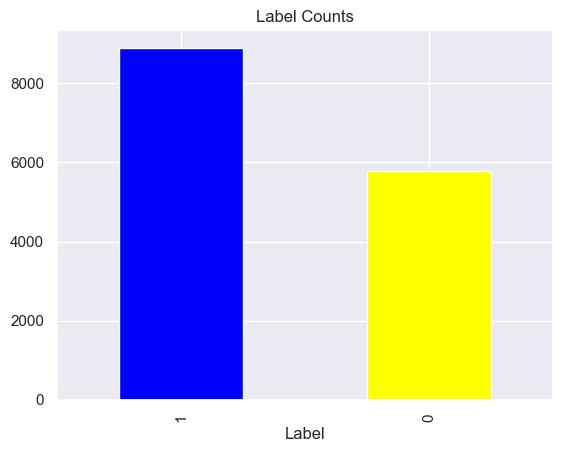

In [11]:
counts = dfD.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1).value_counts()
print(counts)
counts.plot(kind = "bar", color = ["blue", "yellow"])
plt.title("Label Counts")
plt.xlabel("Label")
plt.show()

This reveals a moderate class imbalance (around 61% hypoxic vs 39% normoxic cells). To reduce the impact of this imbalance during training, several strategies could be applied such as stratified train-test splitting, and the use of class weights in classifiers. Also, evaluation metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC, should be used to better assess model performance across both classes.

### **Duplicate Genes**

We also want to see if there are genes that behave the same across all of the cells, seeking to identify redundant genes.

In [12]:
duplicate_data = dfD_t[dfD_t.duplicated()]
print("Number of duplicate genes:", duplicate_data.shape[0], "over", dfD.shape[1])
print("Percentage of duplicate genes:", (duplicate_data.shape[0] * 100) / (dfD_t.shape[0]), "%")

Number of duplicate genes: 0 over 3000
Percentage of duplicate genes: 0.0 %


### **Sample Correlation**

Next, we check the correlation between gene expression profiles of different samples. Just like with SmartSeq, we will use Pearson's Correlation Coefficient for this analysis and a heatmap for visualization.

Given the high dimensionality of this dataset, we will carry out this section of the analysis using just the first 400 cells of the DataFrame.

Average correlation of expression profiles between cells:  0.4994540184930423
Min. correlation of expression profiles between cells:  -0.001091963013915315


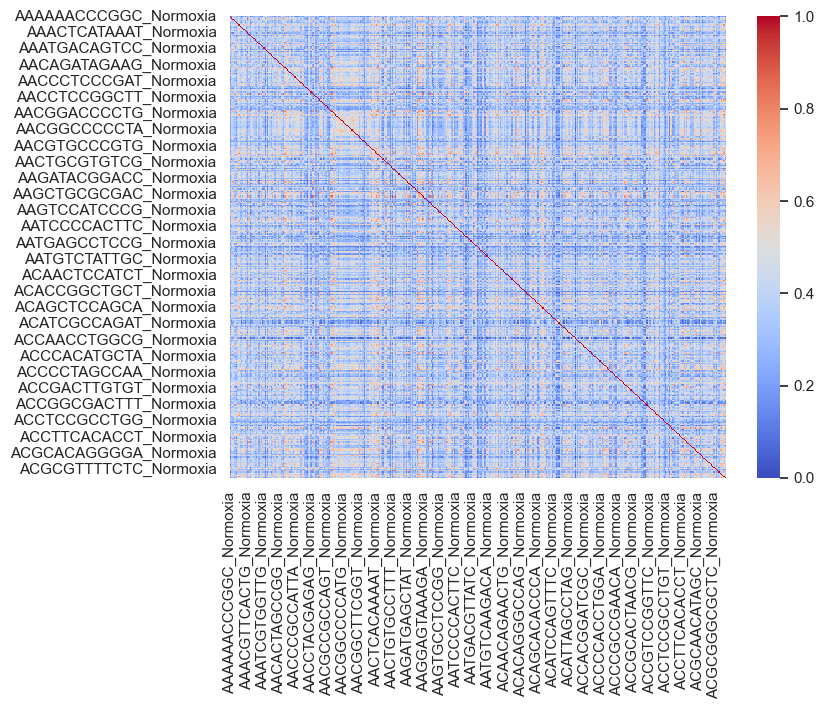

In [13]:
dfD_subset = dfD.iloc[:400, :]

plt.figure(figsize=(8,6))
cor = dfD_subset.T.corr()
mid = (cor.values.max() - cor.values.min()) /2 + cor.values.min()
sns.heatmap(cor,cmap='coolwarm')
print("Average correlation of expression profiles between cells: ", mid)
print("Min. correlation of expression profiles between cells: ", cor.values.min())

The correlation heatmap shows moderate similarity between the cells, with an average correlation of around 0.50. This suggests that the preprocessing steps reduced some of the technical noise while still keeping important biological differences in the dataset. There are no strong block-like patterns in the heatmap, which suggests the data are not made up of highly similar or duplicated cell groups. The minimum correlation value being close to zero also shows that some cells still have quite different expression profiles, which could reflect real differences between hypoxic and normoxic cell states. 

Overall, the preprocessing seems to have improved the quality of the data while still keeping meaningful biological variation for later machine learning analysis.


### **Sparsity**

To investigate the sparsity of our file we will quantify it in the same way done for SmartSeq, as a percentage of zero entries in the DataFrame.

In [14]:
total_element = dfD.shape[0] * dfD.shape[1]
print("Total number of elements in the DataFrame:", total_element)
zero_value = (dfD == 0).sum().sum()
print("Total number of zero values in the DataFrame:", zero_value)
sparse = (zero_value / total_element) * 100
print("Sparsity of the DataFrame: {:.2f}%".format(sparse))

Total number of elements in the DataFrame: 44046000
Total number of zero values in the DataFrame: 43005440
Sparsity of the DataFrame: 97.64%


As expected, this is an extremely sparse dataset. This result can be explained with the fact that this is a gene expression matrix, as detailed before, and with the type of sequencing technique used. DropSeq technology is less precise, being able to analyze a large number of samples at the cost of a lower sensitivity for gene expression detection.

Next, we vizualize the sparsity of out data frame we display in a heatmap a boolean table that marks the location of the zero values.

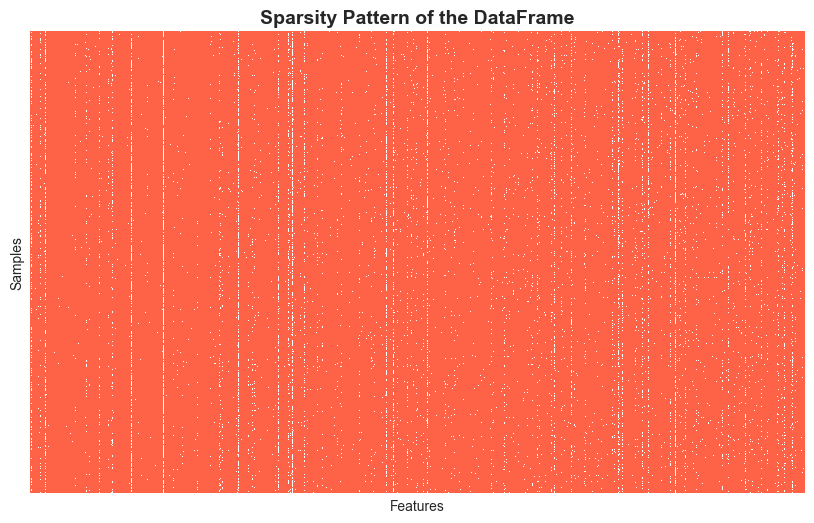

In [15]:
zeroes_mask = dfD == 0
colors = ["#FFFFFF", "#FF6347"] 
plt.figure(figsize=(10, 6))
sns.heatmap(zeroes_mask, cmap=sns.color_palette(colors), cbar=False, xticklabels=False, yticklabels=False)
plt.title('Sparsity Pattern of the DataFrame', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Samples', fontsize=10)
plt.show()

Indeed, almost the entire heatmap being red (zero-value entries) puts it into perspective just how sparse the DataFrame is. 

### **Distribution of the Data**

To quantify the distributional patterns of our data more systematically, we examine the skewness and kurtosis of the gene expression data.

**Skewness** is a measure of symmetry. We will consider the skewness of our data by calculating how skewed each sample's data is, then plotting the distribution of those skewness values.

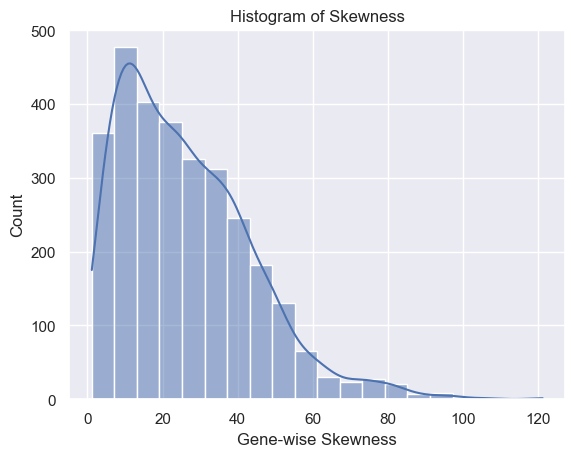

Mean Skewness: 26.30937426592226


In [16]:
skew_values =  [skew(dfD[col]) for col in dfD.columns]
sns.histplot(skew_values,kde=True, bins=20)
plt.title("Histogram of Skewness")
plt.xlabel("Gene-wise Skewness")
plt.show()
print("Mean Skewness:", np.mean(skew_values))


This shows us that the data is strongly positively skewed, meaning most genes have low expression values across cells while a smaller number of genes show much higher expression. Again, this is expected given the background of our data, reflecting the biological variability and sparsity typically seen in gene expression datasets.


**Kurtosis** describes the shape of a distribution's tails, identifying how often extreme outliers occur with respect to a normal distribution. Higher kurtosis means a higher frequency of extreme outliers, which is what we expect from our data considering the previous analysis conducted on the outliers in our data.

Similarly to the analysis of skewness, we will proceed by calculating the kurtosis for each sample's data and then plotting the distribution of those kurtosis values.

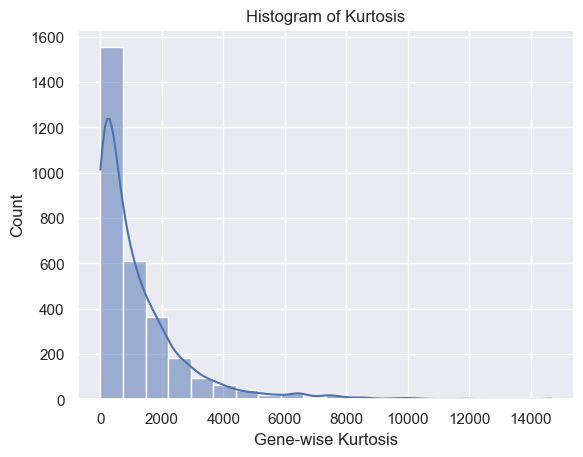

Mean Kurtosis: 1202.769385820414


In [17]:
kurt_value =  [kurtosis(dfD[col]) for col in dfD.columns]

sns.histplot(kurt_value,kde=True, bins=20)
plt.title("Histogram of Kurtosis")
plt.xlabel("Gene-wise Kurtosis")
plt.show()
print("Mean Kurtosis:", np.mean(kurt_value))

This indicates heavy tails and the presence of outliers in the distributions, meaning that while most genes have relatively low or moderate expression levels, some genes show extremely high expression in certain cells. Again, this common given the context of our data as it reflects the biological heterogeneity present between cells
